# Clase 16: El modelo Black–Scholes

*Intuición, importancia y rol en finanzas modernas*

## 1. El problema central: ¿cómo se debe valuar una opción?

Una opción es un contrato cuyo valor depende del comportamiento futuro de un activo.

Por ejemplo, el payoff de una call europea es:

$$
\max(S_T - K,\ 0)
$$

Esto plantea una pregunta fundamental: ¿cuánto debería valer hoy ese contrato?

A diferencia de una acción, cuyo precio se observa directamente en el mercado, el valor de una opción depende de:

- la incertidumbre futura del precio
- el tiempo restante
- la magnitud de los movimientos posibles del activo — no de su dirección

Esta última distinción es clave y adelanta uno de los resultados más sorprendentes del modelo.

Durante mucho tiempo no existía una forma rigurosa de responder esta pregunta. El modelo Black–Scholes, desarrollado en 1973 por Fischer Black, Myron Scholes y Robert Merton, cambió esto radicalmente. Por primera vez se obtuvo una forma matemática consistente de valuar opciones. Este resultado transformó los mercados financieros y dio origen a gran parte de las finanzas cuantitativas modernas.

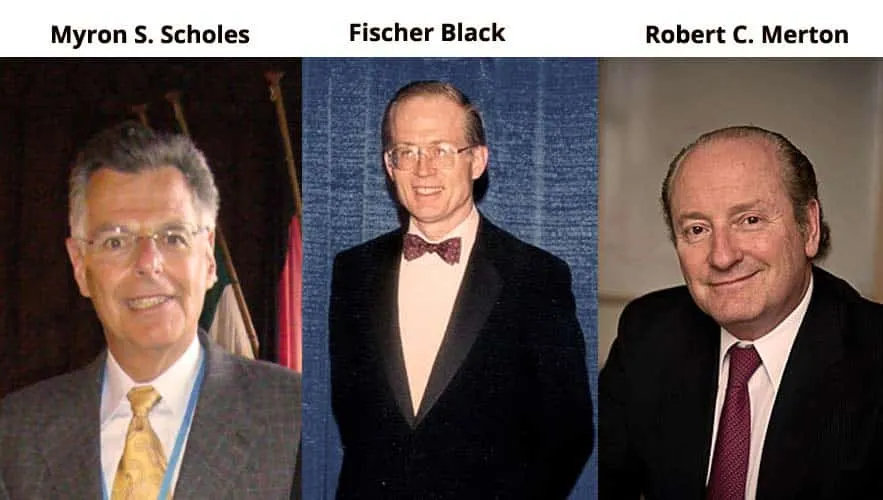

---

## 2. La idea revolucionaria: eliminar el riesgo

La intuición central de Black–Scholes es sorprendente.

En lugar de intentar predecir el precio futuro del activo, el modelo se basa en una idea distinta:

> Si podemos construir un portafolio que replique exactamente el payoff de la opción, entonces el precio de la opción debe ser igual al costo de ese portafolio.
> 

Este principio se basa en la condición de no arbitraje.

Si la opción tuviera un precio distinto al del portafolio replicante, existiría una oportunidad de ganancia sin riesgo:

- si la opción es más cara que el portafolio replicante → vender la opción y comprar el portafolio
- si es más barata → comprar la opción y vender el portafolio

Este mecanismo forzaría los precios a coincidir.

La construcción concreta que propusieron Black y Scholes es la siguiente: aunque no se puede saber qué camino tomará el precio del activo en el futuro, sí es posible construir en cada momento una posición cubierta — una posición larga en el activo y una posición corta en la opción — cuyo valor no depende del precio del activo. Es decir, los movimientos del activo se cancelan entre sí dentro del portafolio.

Esta estrategia de cobertura dinámica conduce a una ecuación diferencial parcial que gobierna el precio de la opción. Su solución es precisamente la fórmula de Black–Scholes.

---

## 3. La dinámica del precio del activo

El modelo parte de una hipótesis sobre cómo evoluciona el precio del activo.

Intuitivamente: el precio de mañana depende del precio de hoy más un shock aleatorio proporcional al precio. Formalmente, se asume que sigue un movimiento geométrico browniano:

$$
dS = \mu S\, dt + \sigma S\, dW
$$

donde:

- $S$ = precio del activo
- $\mu$ = rendimiento esperado
- $\sigma$ = volatilidad
- $W$ = movimiento browniano

Esta ecuación implica varias cosas importantes:

- los retornos logarítmicos son normales
- la volatilidad es constante
- el precio siempre es positivo
- la incertidumbre crece con el tiempo

Esta hipótesis es una idealización, pero captura razonablemente bien el comportamiento de los precios financieros.

---

## 4. El resultado clave: el rendimiento esperado desaparece

Una de las conclusiones más sorprendentes del modelo es que el precio de la opción no depende del rendimiento esperado del activo.

El parámetro $\mu$ desaparece de la fórmula final.

Esto ocurre porque el portafolio replicante elimina el riesgo. Una vez que el riesgo se elimina, el portafolio debe crecer a la tasa libre de riesgo.

Este resultado lleva al concepto fundamental de medida neutral al riesgo. Bajo esta medida, podemos valorar derivados como si el activo creciera a la tasa libre de riesgo.

Esto no describe el mundo real, pero permite calcular precios consistentes con ausencia de arbitraje.

Nota cómo esto conecta con lo que dijimos en la sección 1: el precio de la opción depende de cuánto puede moverse el activo ($\sigma$), no de hacia dónde se espera que vaya ($\mu$). Esa asimetría es la esencia del modelo.

---

## 5. La fórmula de Black–Scholes

El resultado final del modelo es una fórmula cerrada para el precio de una call europea:

$$
C = S_0\, N(d_1) - K e^{-rT} N(d_2)
$$

donde:

$$
d_1 = \frac{\ln(S_0/K) + \left(r + \dfrac{\sigma^2}{2}\right)T}{\sigma\sqrt{T}}
$$

$$
d_2 = d_1 - \sigma\sqrt{T}
$$

Esta fórmula conecta variables observables del mercado: *precio actual, volatilidad, tiempo al vencimiento, tasa libre de riesgo y strike*, con el precio de la opción.

---

## 6. La intuición de $d_1$ y $d_2$

A primera vista la fórmula parece una expresión técnica y muy compleja sin interpretación clara. Pero tiene una lectura económica muy precisa.

### La estructura de la fórmula

Observa que la fórmula tiene dos términos:

$$
C = \underbrace{S_0\, N(d_1)}_{\text{lo que recibes}} - \underbrace{K e^{-rT} N(d_2)}_{\text{lo que pagas}}
$$

Una call europea te da derecho a recibir el activo y pagar el strike. La fórmula refleja exactamente eso, ajustado por probabilidades.

### ¿Qué es $N(d_2)$?

$N(d_2)$ es la probabilidad, bajo la medida neutral al riesgo, de que la opción termine dentro del dinero al vencimiento:

$$
N(d_2) = \mathbb{Q}(S_T > K)
$$

El segundo término completo:

$$
K e^{-rT}\, N(d_2)
$$

es el valor presente del strike, ponderado por la probabilidad de que efectivamente lo tengas que pagar.

### ¿Qué es $N(d_1)$?

$N(d_1)$ es más sutil. No es simplemente la probabilidad de ejercer la opción.

Para entenderlo, hay que notar que $N(d_2)$ responde a la pregunta: ¿con qué probabilidad termina la opción en el dinero? Pero esa probabilidad trata todos los escenarios por igual, sin importar qué tan arriba esté el activo cuando se ejerza.

$N(d_1)$ responde a una pregunta distinta: ¿cuánto vale el activo en promedio, ponderando solo los escenarios donde la opción se ejerce? Los escenarios donde el activo termina muy por encima del strike pesan más, porque en esos casos recibes más valor.

En términos prácticos:

$$
S_0\, N(d_1)
$$

es el valor presente del activo condicionado a que la opción se ejerza. No es solo una probabilidad — es una probabilidad ajustada por el tamaño de la ganancia potencial en cada escenario.

### Por qué $d_1 \neq d_2$

La diferencia entre ambos es exactamente $\sigma\sqrt{T}$:

$$
d_1 = d_2 + \sigma\sqrt{T}
$$

Esta diferencia refleja la asimetría del payoff. Cuando la opción se ejerce, recibes el activo y en los escenarios donde se ejerce, el activo tiende a valer más que su valor esperado incondicional. Eso empuja $N(d_1)$ hacia arriba respecto de $N(d_2)$.

A mayor volatilidad o mayor tiempo, más grande es esa asimetría.

### La lectura completa

> *El valor de la call es lo que esperas recibir del activo en los escenarios favorables, menos lo que esperas pagar por el strike en esos mismos escenarios.*
> 

$N(d_2)$ captura la probabilidad simple de ejercer. $N(d_1)$ captura esa misma probabilidad pero ponderada por el valor del activo en cada escenario. La diferencia entre ambos — $\sigma\sqrt{T}$ — es exactamente lo que separa una probabilidad plana de una probabilidad ajustada por magnitud. Ese es el contenido real de la fórmula.

---

## 7. La verdadera importancia del modelo

Aunque la fórmula es famosa, la verdadera importancia de Black–Scholes no es solo la fórmula. Sus contribuciones más profundas son:

### 1. Introduce el principio de no arbitraje en derivados

El precio de un derivado se determina por replicación.

### 2. Introduce el hedging dinámico

El riesgo de una opción puede eliminarse ajustando continuamente la posición en el activo. Esto se conoce como delta hedging.

### 3. Introduce la medida neutral al riesgo

Permite calcular precios usando probabilidades ajustadas al mercado.

### 4. Da origen a las Greeks

Sensibilidades del precio de la opción: delta, gamma, theta y vega. Estas son herramientas fundamentales para gestión de riesgo.

---

## 8. El cambio conceptual más importante para nosotros: volatilidad implícita

Hasta ahora, en nuestras simulaciones hemos utilizado volatilidad histórica — es decir, la volatilidad calculada a partir de retornos pasados.

Pero el mercado de opciones utiliza un enfoque distinto.

El precio de mercado de una opción ya contiene información sobre las expectativas del mercado. Podemos tomar el precio observado de la opción e invertir la fórmula de Black–Scholes para encontrar la volatilidad que lo explica.

Esta volatilidad se llama **volatilidad implícita** $(\sigma_{\text{implícita}})$.

Conceptualmente:

$$
\text{precio de mercado} \xrightarrow{\text{BS}^{-1}} \sigma_{\text{implícita}}
$$

Esta volatilidad representa la incertidumbre que el mercado está descontando hacia el futuro.

---

## 9. Por qué la volatilidad implícita es tan importante

La volatilidad implícita es una de las variables más importantes en los mercados de derivados. Se usa para:

- comparar opciones
- medir expectativas de riesgo
- construir superficies de volatilidad
- calibrar modelos

En la práctica, muchos modelos no intentan predecir precios directamente. En cambio, se calibran para reproducir la volatilidad implícita observada en el mercado.

---

## 10. Conexión con los métodos que veremos

En este curso utilizaremos varios métodos para valuar opciones:

- **Black–Scholes**: modelo analítico para opciones europeas
- **Árboles binomiales**: permiten valuar opciones americanas con ejercicio temprano
- **Monte Carlo**: permite valuar opciones exóticas y derivados dependientes de trayectoria

Sin embargo, incluso cuando usamos Monte Carlo, la volatilidad que alimenta el modelo muchas veces proviene de Black–Scholes, a través de la volatilidad implícita. Esto muestra que el modelo sigue siendo una pieza central de las finanzas modernas.

---

## 11. Limitaciones del modelo

El modelo hace varias suposiciones simplificadoras que en la práctica no se cumplen estrictamente. Todas ellas apuntan al mismo problema de fondo: la volatilidad no es constante ni directamente observable.

- volatilidad constante
- ausencia de costos de transacción
- mercados continuos
- dinámica lognormal de precios

En la práctica observamos fenómenos como:

- volatility smile
- volatility skew
- saltos en precios

Esto ha llevado al desarrollo de modelos más avanzados: volatilidad estocástica, modelos de salto-difusión y modelos de volatilidad local. Sin embargo, incluso estos modelos suelen calibrarse utilizando volatilidades implícitas derivadas de Black–Scholes.

---

## Lo que este modelo dejó como legado

El modelo Black–Scholes es uno de los pilares de las finanzas cuantitativas. Su importancia no radica solo en la fórmula que produce, sino en las ideas que introduce:

- valuación por no arbitraje
- replicación de portafolios
- hedging dinámico
- medida neutral al riesgo
- volatilidad implícita

Estas ideas siguen siendo la base conceptual de prácticamente todos los modelos modernos de derivados.